In [1]:
import os
print(os.getcwd())

e:\FakeReviewDetection


In [2]:
# 1 Improve the Text Preprocessing

# Run once
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\madhu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\madhu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\madhu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\madhu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\madhu\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
from utils.preprocess import clean_reviews

sample = "Amazing Product!!! Worth buying 100%."
print(clean_reviews(sample))

amazing product worth buying


In [4]:
# 2 Apply Preprocessing to the Dataset
import pandas as pd

# Then use your preprocessing functions
from utils.preprocess import clean_reviews

# Load your cleaned dataset.
df = pd.read_csv(r"E:\FakeReviewDetection\dataset\clean_reviews.csv")

# Create a new column
df["clean_review"] = df["text"].apply(clean_reviews)


In [5]:
# Check the result
print(df[["text", "clean_review", "deceptive"]].head())

                                                text  \
0  We stayed for a one night getaway with family ...   
1  Triple A rate with upgrade to view room was le...   
2  This comes a little late as I'm finally catchi...   
3  The Omni Chicago really delivers on all fronts...   
4  I asked for a high floor away from the elevato...   

                                        clean_review deceptive  
0  stayed one night getaway family thursday tripl...  truthful  
1  triple rate upgrade view room less also includ...  truthful  
2  come little late im finally catching review pa...  truthful  
3  omni chicago really delivers front spaciousnes...  truthful  
4  asked high floor away elevator got room pleasa...  truthful  


In [6]:
# Save the new dataset
df.to_csv(r"E:\FakeReviewDetection\dataset\preprocessed_reviews.csv", index=False)
print("saved the preprocessed data")

saved the preprocessed data


In [7]:
print(df["deceptive"])


0        truthful
1        truthful
2        truthful
3        truthful
4        truthful
          ...    
1591    deceptive
1592    deceptive
1593    deceptive
1594    deceptive
1595    deceptive
Name: deceptive, Length: 1596, dtype: str


In [8]:
# 3 Convert Labels=deceptive to Numbers
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["deceptive"] = encoder.fit_transform(df["deceptive"])

In [9]:
print(df['deceptive'])

0       1
1       1
2       1
3       1
4       1
       ..
1591    0
1592    0
1593    0
1594    0
1595    0
Name: deceptive, Length: 1596, dtype: int64


In [10]:
# 4 Split Features and Labels
x = df["clean_review"]
y = df["deceptive"]

In [11]:
# 5 Train-Test Split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
    )

80% → Training

20% → Testing

In [12]:
print(type(x_train))

<class 'pandas.Series'>



6: TF-IDF  (Term Frequency - Inverse Document Frequency) Vectorization  
Convert text into numbers.

Review ->
TF-IDF ->
Machine Learning understands numbers

In [13]:
# 6: TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

x_train = tfidf.fit_transform(x_train)

x_test = tfidf.transform(x_test)

In [14]:
# 7: Train Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [ ]:
# 8: Make Predictions or Test the model
predictions = model.predict(x_test)

In [ ]:
# 9: Evaluate the Model 
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,classification_report,confusion_matrix
print("accuracy:",accuracy_score(y_test, predictions))
print("precision:",precision_score(y_test, predictions))
print("recall:",recall_score(y_test, predictions))
print("f1_score:",f1_score(y_test, predictions))
print("classification_report:",classification_report(y_test, predictions))
print("confusion_matrix:",confusion_matrix(y_test, predictions))


accuracy: 0.85625
precision: 0.8544303797468354
recall: 0.8544303797468354
f1_score: 0.8544303797468354
classification_report:               precision    recall  f1-score   support

           0       0.86      0.86      0.86       162
           1       0.85      0.85      0.85       158

    accuracy                           0.86       320
   macro avg       0.86      0.86      0.86       320
weighted avg       0.86      0.86      0.86       320

confusion_matrix: [[139  23]
 [ 23 135]]


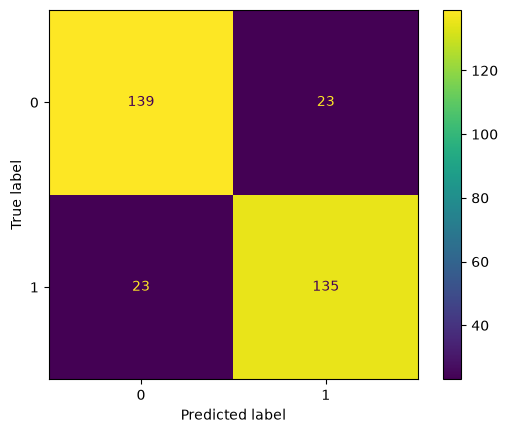

In [17]:
# 10 Visualize the Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, predictions)

plt.show()

In [18]:
# 11: Save the Model
import joblib
joblib.dump(model, "models/model.pkl")

['models/model.pkl']

In [19]:
# 12: Save the TF-IDF Vectorizer
joblib.dump(tfidf, "models/tfidf.pkl")

['models/tfidf.pkl']

TF-IDF = Translator

Model  = Decision Maker

In [ ]:
# 13: Test the Saved Model  or   Flask loads them
model = joblib.load("models/model.pkl")

tfidf = joblib.load("models/tfidf.pkl")

In [21]:
review = ["This product is amazing and worth every penny"]

review = tfidf.transform(review)

prediction = model.predict(review)

print(prediction)

[1]


In [22]:
print(encoder.classes_)

['deceptive' 'truthful']


In [23]:
print(df["deceptive"].unique())

[1 0]


In [24]:
print(model.classes_)

[0 1]
